# Phase 4 — Dubins sampling-time sweep (our Phase-1.3 controller)

## Test design (mirrors `dubins_sampling_sweep_mpc.ipynb`)

- **Fixed physical horizon** `T_hor = dt x N = 1.25 s` for every config; dt
  values divide 1.25 exactly so `N = T_hor/dt` is integer.
- **All candidates tested** for every (method, dt); `success = REACHED`
  (closed-loop trajectory enters the target, `phi <= phi_tol`).
  First-step infeasibility counts as failure.
- **Safety margin is a DIAGNOSTIC** (`min_safety_margin`), not a gate -- the
  small inter-sample sampled-data dip shrinks as dt shrinks (Lemma 2) and is
  reported, not used to fail a trajectory.

|  dt (s)   |   N    |      T_hor (s)      |
| :-------: | :----: | :-----------------: |
|   0.025   |   50   |        1.25         |
| **0.050** | **25** | **1.25** (baseline) |
|   0.125   |   10   |        1.25         |
|   0.250   |   5    |        1.25         |

**What differs from the reference:** the RA-MPC terminal set is OUR
`dubins_constrained.py` certificate, and both MPC methods use OUR
`u_max_eff` actuator bounds from Phase 1.3 (not the main-repo controller /
the symmetric `|u|<=5`). Needs casadi + joblib + scipy + sympy (env `rab_mpc`).


## §1 — Load our controller + bounds; define sets/dynamics


In [20]:
import sys, os, time, json, importlib.util
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import casadi as ca
import pandas as pd
from scipy.integrate import solve_ivp
from joblib import Parallel, delayed

# locate ROOT via revision/matlab_frozen (no reference to the main repo)
ROOT = os.path.abspath(os.getcwd())
for _ in range(6):
    if os.path.isdir(os.path.join(ROOT, "revision", "matlab_frozen")):
        break
    ROOT = os.path.dirname(ROOT)
REV = os.path.join(ROOT, "revision")
CTRL = os.path.join(REV, "controllers")
REV_DATA = os.path.join(REV, "data")

# --- our Phase-1.3 RA controller (certificate = RA-MPC terminal set) + bounds
with open(os.path.join(REV_DATA, "phase1_3_meta_dubins.json")) as fh:
    meta = json.load(fh)
U_MAX = [float(meta["u_max_eff"]["omega"]), float(meta["u_max_eff"]["a"])]
u1_max, u2_max = U_MAX

spec = importlib.util.spec_from_file_location(
    "dubins_constrained", os.path.join(CTRL, "dubins_constrained.py")
)
ra_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ra_mod)
cert = sp.sympify(ra_mod.certificate_opt)

# --- Dubins dynamics + sets (frozen example) ------------------------------
x1, x2, th, v = sp.symbols("x1 x2 th v")
y1, y2 = sp.symbols("y1 y2")
state_vars = [x1, x2, th, v]
hx = sp.Matrix([x1, x2])
h_raw = -(y1**4 + y2**4 - 16) * (y1**4 + y2**4 - 4)
target_set_y = (y2 - 0) ** 2 + ((y1 + 1.7) / 0.5) ** 2 - 0.4
safe_set_y = 1e-3 * (-target_set_y + 300) * h_raw
safe_set_x = safe_set_y.subs({y1: hx[0], y2: hx[1]})
target_set_x = target_set_y.subs({y1: hx[0], y2: hx[1]})
safe_set_x_func = sp.lambdify(state_vars, safe_set_x, "numpy")
target_set_x_func = sp.lambdify(state_vars, target_set_x, "numpy")
safe_set_y_func = sp.lambdify([y1, y2], safe_set_y, "numpy")
target_set_y_func = sp.lambdify([y1, y2], target_set_y, "numpy")
hx_func = sp.lambdify(state_vars, hx, "numpy")
print("RA terminal = our dubins_constrained.py cert | u_max_eff =", U_MAX)

RA terminal = our dubins_constrained.py cert | u_max_eff = [7.7, 5.1]


## §2 — CasADi: certificate / safe set / RK4 factory


In [21]:
def sympy2casadi(expr, sym_map):
    if isinstance(
        expr,
        (
            sp.Integer,
            sp.Float,
            sp.Rational,
            sp.core.numbers.NegativeOne,
            sp.core.numbers.Half,
            sp.core.numbers.One,
            sp.core.numbers.Zero,
            sp.core.numbers.Pi,
        ),
    ):
        return float(expr)
    if isinstance(expr, sp.Symbol):
        return sym_map[expr]
    if isinstance(expr, sp.Add):
        return sum(sympy2casadi(a, sym_map) for a in expr.args)
    if isinstance(expr, sp.Mul):
        r = 1.0
        for a in expr.args:
            r = r * sympy2casadi(a, sym_map)
        return r
    if isinstance(expr, sp.Pow):
        return sympy2casadi(expr.args[0], sym_map) ** sympy2casadi(
            expr.args[1], sym_map
        )
    if isinstance(expr, sp.sin):
        return ca.sin(sympy2casadi(expr.args[0], sym_map))
    if isinstance(expr, sp.cos):
        return ca.cos(sympy2casadi(expr.args[0], sym_map))
    if isinstance(expr, sp.Number):
        return float(expr)
    raise ValueError(f"Unsupported sympy type: {type(expr)}")


ca_x1 = ca.SX.sym("x1")
ca_x2 = ca.SX.sym("x2")
ca_th = ca.SX.sym("th")
ca_v = ca.SX.sym("v")
sym_map = {x1: ca_x1, x2: ca_x2, th: ca_th, v: ca_v}
cert_ca_f = ca.Function(
    "cert", [ca_x1, ca_x2, ca_th, ca_v], [sympy2casadi(cert, sym_map)]
)
safe_ca_f = ca.Function(
    "safe", [ca_x1, ca_x2, ca_th, ca_v], [sympy2casadi(safe_set_x, sym_map)]
)


def cert_vec(xv):
    return cert_ca_f(xv[0], xv[1], xv[2], xv[3])


def safe_vec(xv):
    return safe_ca_f(xv[0], xv[1], xv[2], xv[3])


xc_g = ca.SX.sym("x", 4)
uc_g = ca.SX.sym("u", 2)
fc_g = ca.vertcat(
    xc_g[3] * ca.cos(xc_g[2]), xc_g[3] * ca.sin(xc_g[2]), uc_g[0], uc_g[1]
)
rhs_ca_g = ca.Function("f", [xc_g, uc_g], [fc_g])


def make_F_disc(dt):
    k1 = rhs_ca_g(xc_g, uc_g)
    k2 = rhs_ca_g(xc_g + dt / 2 * k1, uc_g)
    k3 = rhs_ca_g(xc_g + dt / 2 * k2, uc_g)
    k4 = rhs_ca_g(xc_g + dt * k3, uc_g)
    return ca.Function(
        "F_disc", [xc_g, uc_g], [xc_g + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)]
    )


def h_ca(xv):
    return ca.vertcat(xv[0], xv[1])


def safe_ca(x):
    y1v, y2v = x[0], x[1]
    h = -(y1v**4 + y2v**4 - 16) * (y1v**4 + y2v**4 - 4)
    tgt = (y2v) ** 2 + ((y1v + 1.7) / 0.5) ** 2 - 0.4
    return 1e-3 * (-tgt + 300) * h


def target_ca(x):
    return (x[1]) ** 2 + ((x[0] + 1.7) / 0.5) ** 2 - 0.4


print("CasADi functions built.")

CasADi functions built.


## §3 — Sweep config (fixed T_hor = 1.25 s) + candidate set


In [22]:
T_HOR_FIXED = 1.25
N_CANDIDATES = 300
T_max = 10.0
phi_tol = 0.05
TARGET_POS = np.array([-1.7, 0.0])
_IPOPT_OPTS = {
    "ipopt.print_level": 0,
    "print_time": 0,
    "ipopt.max_iter": 600,
    "ipopt.tol": 1e-4,
    "ipopt.acceptable_tol": 1e-3,
}
DT_N_PAIRS = [(0.025, 50), (0.050, 25), (0.125, 10), (0.250, 5)]
CONFIGS = [
    {"dt_mpc": dt, "N_hor": N, "T_hor_actual": round(N * dt, 4)} for dt, N in DT_N_PAIRS
]
for c in CONFIGS:
    assert abs(c["T_hor_actual"] - T_HOR_FIXED) < 1e-9
print(
    f"T_hor = {T_HOR_FIXED}s fixed | success = REACHED / {N_CANDIDATES} | u_max_eff = {U_MAX}"
)

# 300 candidates: safe & outside target (same seed/box as the paper)
np.random.seed(42)
lb_box = np.array([-2.0, -2.0, 2 * np.pi / 3, -1.0])
ub_box = np.array([2.0, 2.0, 4 * np.pi / 3, 1.0])
x_pool = np.random.rand(4, 1000) * (ub_box - lb_box).reshape(-1, 1) + lb_box.reshape(
    -1, 1
)
safe_v = np.atleast_1d(np.squeeze(safe_set_x_func(*x_pool)))
tgt_v = np.atleast_1d(np.squeeze(target_set_x_func(*x_pool)))
cand_idx = np.where((safe_v >= 0) & (tgt_v > 0))[0][:N_CANDIDATES]
x_cands = x_pool[:, cand_idx]
print(f"{x_cands.shape[1]} candidates selected (seed=42).")

T_hor = 1.25s fixed | success = REACHED / 300 | u_max_eff = [7.7, 5.1]
300 candidates selected (seed=42).


## §4 — MPC solver factory + closed-loop simulation


In [23]:
def make_solver(dt, N, method):
    """method = 'vanilla' (target terminal) or 'ra' (our certificate terminal)."""
    F = make_F_disc(dt)

    def solve(x0_val, U_warm=None):
        opti = ca.Opti()
        X = opti.variable(4, N + 1)
        U_var = opti.variable(2, N)
        x0 = np.asarray(x0_val, float).flatten()
        opti.subject_to(X[:, 0] == x0)
        for k in range(N):
            opti.subject_to(X[:, k + 1] == F(X[:, k], U_var[:, k]))
            opti.subject_to(
                (safe_ca(X[:, k]) if method == "vanilla" else safe_vec(X[:, k])) >= 0
            )
        if method == "vanilla":
            opti.subject_to(safe_ca(X[:, N]) >= 0)
            opti.subject_to(target_ca(X[:, N]) <= 0)
        else:
            opti.subject_to(safe_vec(X[:, N]) >= 0)
            opti.subject_to(cert_vec(X[:, N]) >= 0)
        opti.subject_to(opti.bounded(-u1_max, U_var[0, :], u1_max))
        opti.subject_to(opti.bounded(-u2_max, U_var[1, :], u2_max))
        tgt = ca.DM(TARGET_POS)
        Q = ca.DM([[5.0, 0], [0, 5.0]])
        Qf = ca.DM([[80.0, 0], [0, 80.0]])
        R = ca.DM([[0.05, 0], [0, 0.05]])
        cost = 0
        for k in range(N):
            dy = h_ca(X[:, k]) - tgt
            cost += dy.T @ Q @ dy + U_var[:, k].T @ R @ U_var[:, k]
        cost += (h_ca(X[:, N]) - tgt).T @ Qf @ (h_ca(X[:, N]) - tgt)
        opti.minimize(cost)
        if U_warm is not None:
            U_ws = np.hstack([U_warm[:, 1:], U_warm[:, -1:]])
            X_ws = np.zeros((4, N + 1))
            X_ws[:, 0] = x0
            for k in range(N):
                xk, uk = X_ws[:, k], U_ws[:, k]
                X_ws[:, k + 1] = xk + dt * np.array(
                    [xk[3] * np.cos(xk[2]), xk[3] * np.sin(xk[2]), uk[0], uk[1]]
                )
            opti.set_initial(X, X_ws)
            opti.set_initial(U_var, U_ws)
        else:
            tgt_f = np.array([TARGET_POS[0], TARGET_POS[1], x0[2], 0.0])
            X_ws = np.array(
                [(1 - k / N) * x0 + (k / N) * tgt_f for k in range(N + 1)]
            ).T
            opti.set_initial(X, X_ws)
            opti.set_initial(U_var, 0)
        opti.solver("ipopt", _IPOPT_OPTS)
        t0 = time.perf_counter()
        try:
            sol = opti.solve()
            return True, sol.value(U_var), (time.perf_counter() - t0) * 1e3
        except Exception:
            return False, None, (time.perf_counter() - t0) * 1e3

    return solve


def simulate_one(x0, solve_fn, dt):
    x = np.asarray(x0, float).copy()
    xs = [x.copy()]
    ts = [0.0]
    t = 0.0
    U_prev = None
    step_ms = []
    n_inf = 0
    eff = 0.0
    while t < T_max - 1e-9:
        if float(np.squeeze(target_set_x_func(*x))) <= 0:
            break
        ok, U_opt, ms = solve_fn(x, U_warm=U_prev)
        step_ms.append(ms)
        if not ok:
            n_inf += 1
            break
        u0 = np.array(U_opt[:, 0]).flatten()
        U_prev = U_opt

        def rhs(_, xx):
            return [
                xx[3] * np.cos(xx[2]),
                xx[3] * np.sin(xx[2]),
                float(u0[0]),
                float(u0[1]),
            ]

        sol = solve_ivp(
            rhs,
            [t, t + dt],
            x,
            method="DOP853",
            rtol=1e-8,
            atol=1e-10,
            max_step=dt / 10,
        )
        if not np.all(np.isfinite(sol.y)):
            break
        x = sol.y[:, -1]
        t += dt
        xs.append(x.copy())
        ts.append(t)
        eff += (u0[0] ** 2 + u0[1] ** 2) * dt
    ts = np.array(ts)
    xs = np.array(xs)
    phi_f = float(np.squeeze(target_set_x_func(*xs[-1])))
    success = phi_f <= phi_tol
    n_steps = len(ts) - 1
    stms = np.array(step_ms) if step_ms else np.array([0.0])
    if success:
        outcome = "REACHED"
    elif n_inf > 0 and n_steps == 0:
        outcome = "INFEASIBLE_STEP1"
    elif n_inf > 0 and n_steps > 0:
        outcome = "INFEASIBLE_MID"
    elif t >= T_max - 1e-9:
        outcome = "TIMEOUT"
    else:
        outcome = "DIVERGED"
    min_margin = float(
        np.min([float(np.squeeze(safe_set_x_func(*xs[k]))) for k in range(len(xs))])
    )
    return {
        "success": success,
        "outcome": outcome,
        "time_to_target": float(ts[-1]) if success else float("nan"),
        "sim_duration": float(ts[-1]),
        "control_effort": eff,
        "min_safety_margin": min_margin,
        "n_infeasible": n_inf,
        "n_steps": n_steps,
        "mean_step_ms": float(stms.mean()),
        "total_solve_ms": float(stms.sum()),
    }


def _run(i, dt, N, method_key):
    return simulate_one(x_cands[:, i], make_solver(dt, N, method_key), dt)


print("Simulation functions ready.")

Simulation functions ready.


## §5 — Run the sweep (4 dt x 2 methods, threads)


In [24]:
# Per-config cache: skip any (method, dt) whose results are already in the raw
# CSV with a MATCHING signature (N_CANDIDATES, seed, u_max_eff). Set
# REGENERATE=True to force a full recompute. The raw CSV is checkpointed after
# every config, so a stopped/crashed run resumes instead of restarting, and
# re-running the notebook to tweak the plots below costs nothing.
REGENERATE = False
RAW_PATH = os.path.join(REV_DATA, "dubins_sweep_raw.csv")
SEED = 42
SIG = {
    "N_CANDIDATES": N_CANDIDATES,
    "seed": SEED,
    "u1_max": round(u1_max, 6),
    "u2_max": round(u2_max, 6),
}


def _sig_ok(row):
    return (
        int(row["N_CANDIDATES"]) == SIG["N_CANDIDATES"]
        and int(row["seed"]) == SIG["seed"]
        and abs(float(row["u1_max"]) - SIG["u1_max"]) < 1e-6
        and abs(float(row["u2_max"]) - SIG["u2_max"]) < 1e-6
    )


# load any cached rows whose signature matches the current setup
cached = pd.DataFrame()
if (not REGENERATE) and os.path.exists(RAW_PATH):
    prev = pd.read_csv(RAW_PATH)
    if all(c in prev.columns for c in SIG):
        cached = prev[prev.apply(_sig_ok, axis=1)].copy()
    print(f"cache: {len(cached)} matching rows in {os.path.basename(RAW_PATH)}")

done_keys = set(zip(cached["method"], cached["dt_mpc"])) if len(cached) else set()
all_rows = cached.to_dict("records") if len(cached) else []

for cfg in CONFIGS:
    dt, N, T_h = cfg["dt_mpc"], cfg["N_hor"], cfg["T_hor_actual"]
    for method_name, method_key in [
        ("Vanilla MPC", "vanilla"),
        ("RA-MPC (ours)", "ra"),
    ]:
        if (method_name, dt) in done_keys:
            print(f"--- dt={dt:.3f}s [{method_name}] CACHED -> skip ---", flush=True)
            continue
        print(
            f"--- dt={dt:.3f}s N={N} T_hor={T_h:.3f}s [{method_name}] ---", flush=True
        )
        tw = time.perf_counter()
        results = Parallel(n_jobs=-1, prefer="threads")(
            delayed(_run)(i, dt, N, method_key) for i in range(N_CANDIDATES)
        )
        wall = time.perf_counter() - tw
        oc = {}
        for r in results:
            oc[r["outcome"]] = oc.get(r["outcome"], 0) + 1
        nr = oc.get("REACHED", 0)
        print(
            f"  {wall:.1f}s wall | REACHED={nr} INF_S1={oc.get('INFEASIBLE_STEP1',0)} "
            f"INF_MID={oc.get('INFEASIBLE_MID',0)} TIMEOUT={oc.get('TIMEOUT',0)} "
            f"DIVERGED={oc.get('DIVERGED',0)} | rate={100*nr/N_CANDIDATES:.1f}%",
            flush=True,
        )
        for i, r in enumerate(results):
            r.update(
                {
                    "dt_mpc": dt,
                    "N_hor": N,
                    "T_hor_actual": T_h,
                    "method": method_name,
                    "cand_id": i,
                    **SIG,
                }
            )
        all_rows.extend(results)
        # checkpoint after every config so a stop/crash never loses computed work
        pd.DataFrame(all_rows).to_csv(RAW_PATH, index=False)

df = pd.DataFrame(all_rows)
print(
    f"\nSweep complete. rows: {len(df)}  (raw CSV checkpointed at {os.path.basename(RAW_PATH)})"
)

cache: 2400 matching rows in dubins_sweep_raw.csv
--- dt=0.025s [Vanilla MPC] CACHED -> skip ---
--- dt=0.025s [RA-MPC (ours)] CACHED -> skip ---
--- dt=0.050s [Vanilla MPC] CACHED -> skip ---
--- dt=0.050s [RA-MPC (ours)] CACHED -> skip ---
--- dt=0.125s [Vanilla MPC] CACHED -> skip ---
--- dt=0.125s [RA-MPC (ours)] CACHED -> skip ---
--- dt=0.250s [Vanilla MPC] CACHED -> skip ---
--- dt=0.250s [RA-MPC (ours)] CACHED -> skip ---

Sweep complete. rows: 2400  (raw CSV checkpointed at dubins_sweep_raw.csv)


## §6 — Summary table + save


In [25]:
summary = (
    df.groupby(["method", "dt_mpc", "N_hor"])
    .agg(
        n_reached=("success", "sum"),
        n_infeas_s1=("outcome", lambda x: (x == "INFEASIBLE_STEP1").sum()),
        n_infeas_mid=("outcome", lambda x: (x == "INFEASIBLE_MID").sum()),
        n_timeout=("outcome", lambda x: (x == "TIMEOUT").sum()),
        mean_ttt=("time_to_target", lambda x: round(np.nanmean(x), 3)),
        worst_safety_margin=("min_safety_margin", lambda x: round(x.min(), 4)),
    )
    .reset_index()
)
summary["success_rate"] = (summary["n_reached"] / N_CANDIDATES * 100).round(1)
cols = [
    "method",
    "dt_mpc",
    "N_hor",
    "n_reached",
    "success_rate",
    "n_infeas_s1",
    "n_infeas_mid",
    "n_timeout",
    "mean_ttt",
    "worst_safety_margin",
]
print("=== Sweep summary (rates out of %d) ===" % N_CANDIDATES)
print(summary[cols].sort_values(["method", "dt_mpc"]).to_string(index=False))
print("\n=== success_rate (%) pivot ===")
print(
    summary.pivot(index="dt_mpc", columns="method", values="success_rate").to_string()
)
# raw CSV is checkpointed in §5; here we (re)derive and save the summary.
summary.to_csv(os.path.join(REV_DATA, "dubins_sweep_summary.csv"), index=False)
print("\nsaved dubins_sweep_summary.csv (raw checkpointed in §5)")

=== Sweep summary (rates out of 300) ===
       method  dt_mpc  N_hor  n_reached  success_rate  n_infeas_s1  n_infeas_mid  n_timeout  mean_ttt  worst_safety_margin
RA-MPC (ours)   0.025     50        289          96.3           10             1          0     0.976              -0.0000
RA-MPC (ours)   0.050     25        251          83.7            9            40          0     0.930              -0.0000
RA-MPC (ours)   0.125     10        187          62.3            7           106          0     0.901              -0.0020
RA-MPC (ours)   0.250      5        171          57.0            4           125          0     0.966              -0.1010
  Vanilla MPC   0.025     50        263          87.7           36             1          0     0.928              -0.0000
  Vanilla MPC   0.050     25        241          80.3           36            23          0     0.903              -0.0000
  Vanilla MPC   0.125     10        169          56.3           41            90          0     0.

## §7 — Plots (each its own figure; main-notebook style)


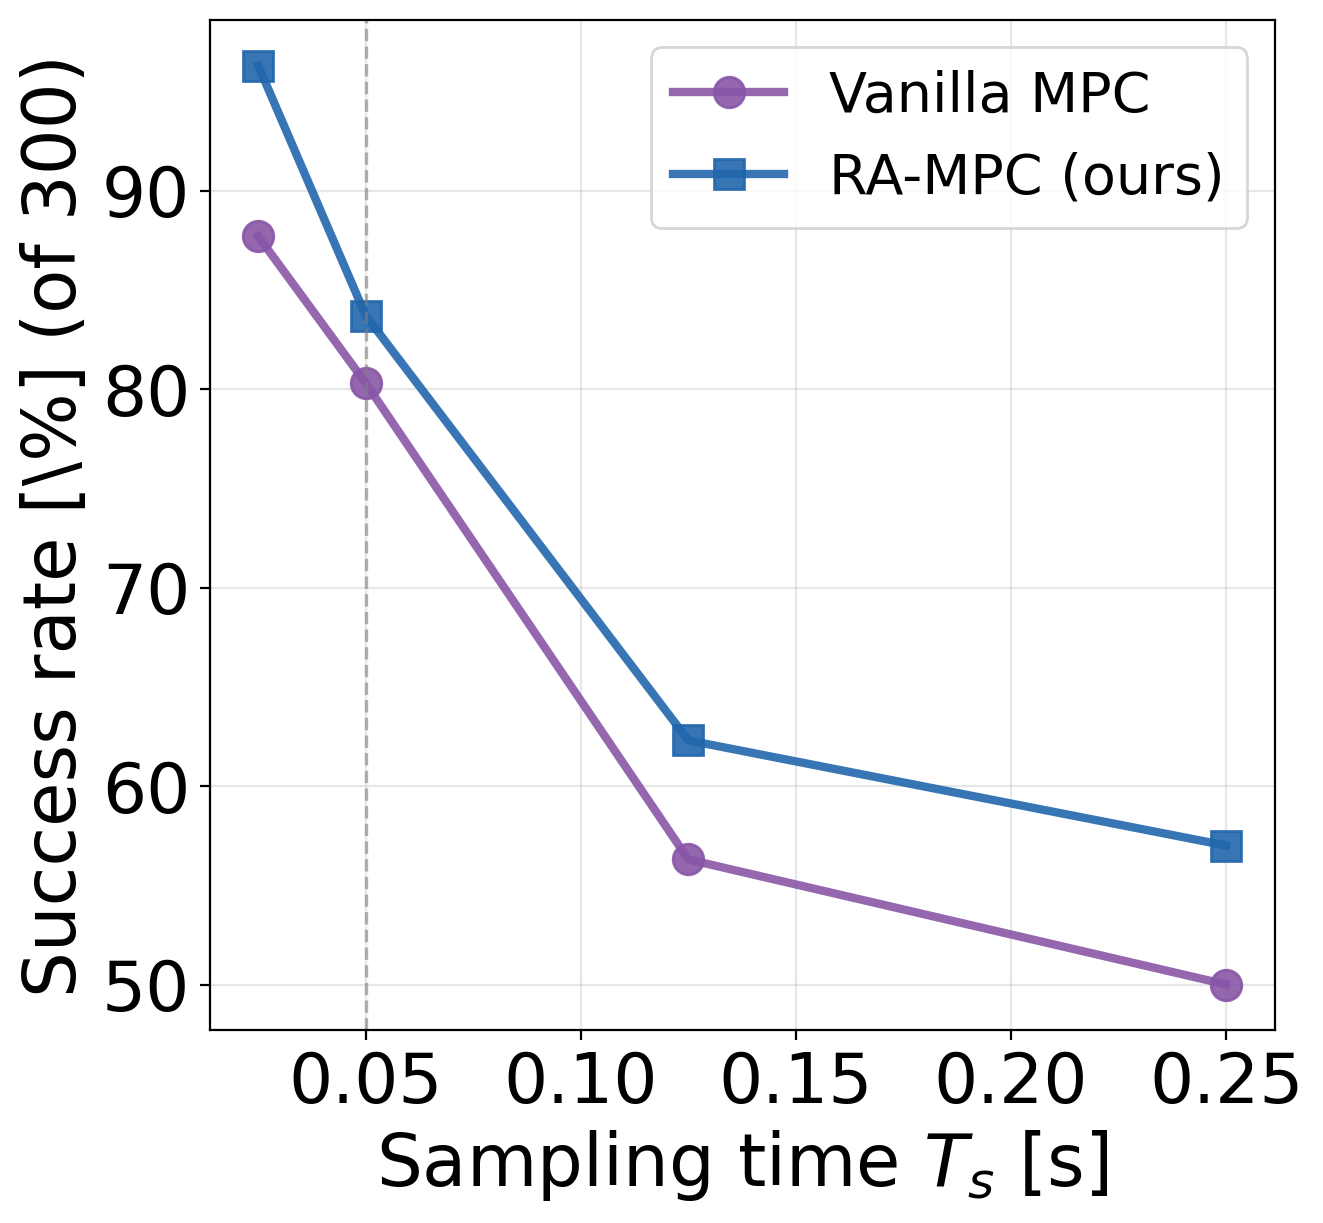

saved dubins_sweep_success_rate.png


In [26]:
# ── Plot 1: success rate vs sampling time ─────────────────────────────────────
# Style follows the main notebooks/: px_fig sizing, fig.set_dpi(200),
# RA = #2166ac (blue), Vanilla = #8856a7 (purple), large fonts, grid alpha 0.3.
methods = ["Vanilla MPC", "RA-MPC (ours)"]
col_c = {"Vanilla MPC": "#8856a7", "RA-MPC (ours)": "#2166ac"}
mk = {"Vanilla MPC": "o", "RA-MPC (ours)": "s"}
fs = 30

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px_fig, 600 * px_fig), layout="constrained")
fig.set_dpi(200)

for m in methods:
    sub = summary[summary["method"] == m].sort_values("dt_mpc")
    ax.plot(
        sub["dt_mpc"],
        sub["success_rate"],
        color=col_c[m],
        marker=mk[m],
        lw=3,
        ms=11,
        alpha=0.9,
        label=m,
    )
ax.axvline(0.05, color="gray", lw=1.2, ls="--", alpha=0.6)
ax.set_xlabel("Sampling time $T_s$ [s]", fontsize=fs - 4)
ax.set_ylabel(f"Success rate [\\%] (of {N_CANDIDATES})", fontsize=fs - 4)
ax.xaxis.set_tick_params(labelsize=25)
ax.yaxis.set_tick_params(labelsize=25)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=20)
fig.savefig(
    os.path.join(REV_DATA, "dubins_sweep_success_rate.png"),
    dpi=200,
    bbox_inches="tight",
)
plt.show()
print("saved dubins_sweep_success_rate.png")

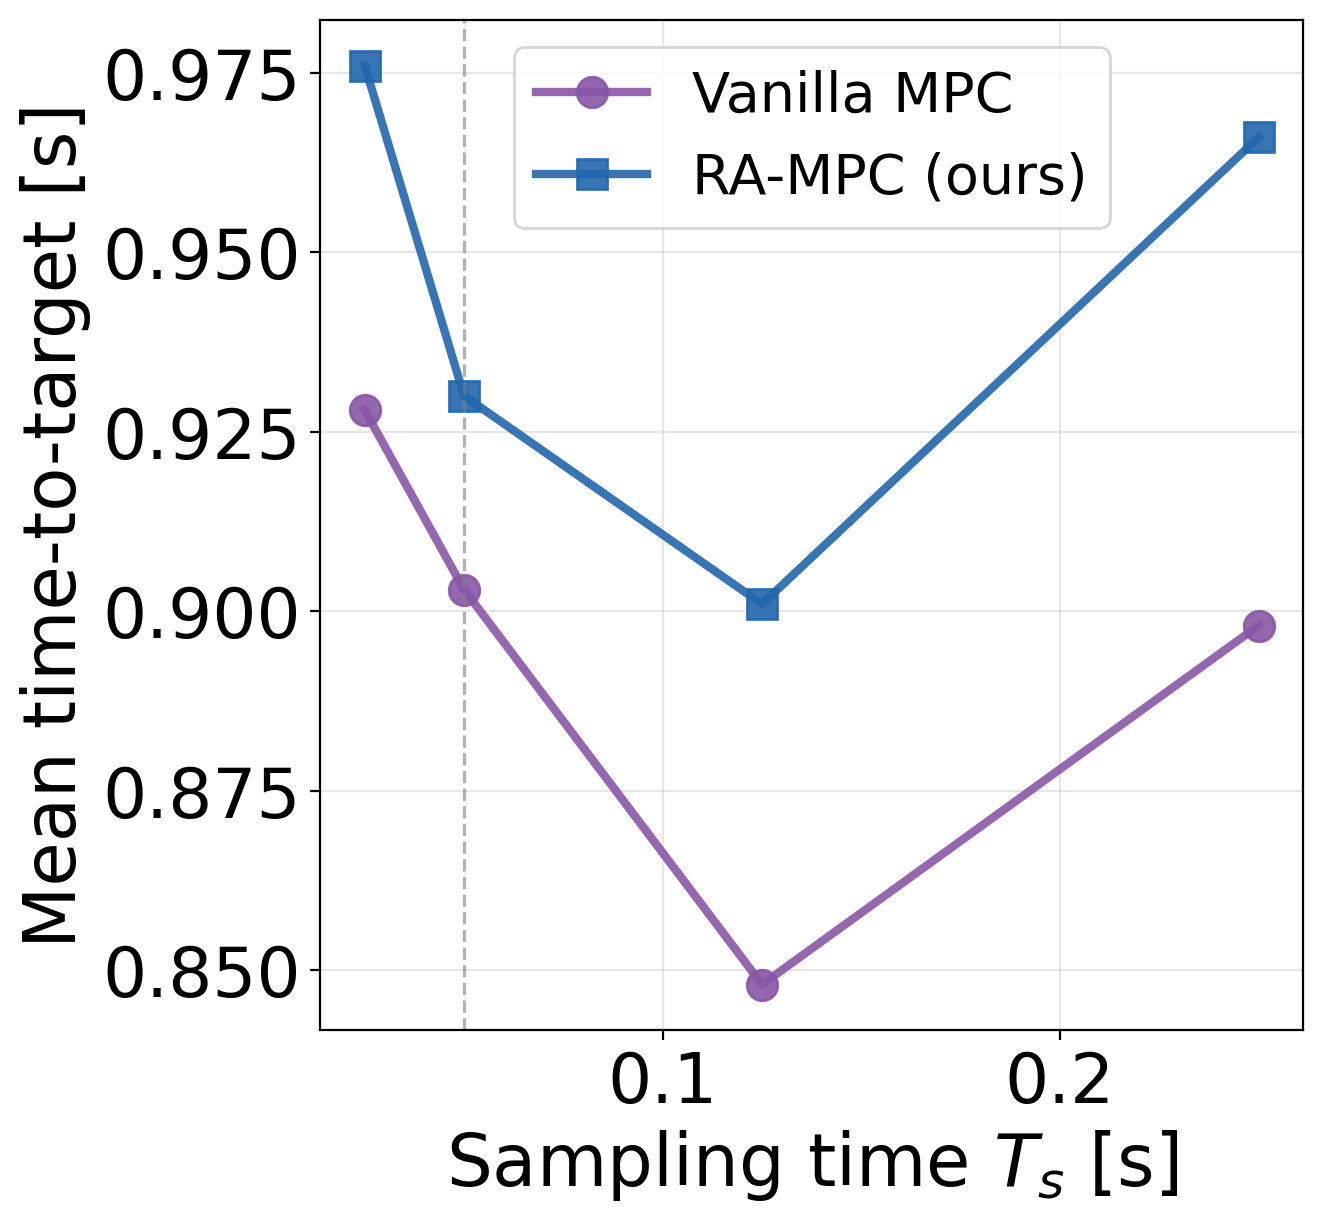

saved dubins_sweep_time_to_target.png


In [27]:
# ── Plot 2: mean time-to-target vs sampling time (successful trajectories) ────
px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px_fig, 600 * px_fig), layout="constrained")
fig.set_dpi(200)

for m in methods:
    sub = summary[summary["method"] == m].sort_values("dt_mpc")
    ax.plot(
        sub["dt_mpc"],
        sub["mean_ttt"],
        color=col_c[m],
        marker=mk[m],
        lw=3,
        ms=11,
        alpha=0.9,
        label=m,
    )
ax.axvline(0.05, color="gray", lw=1.2, ls="--", alpha=0.6)
ax.set_xlabel("Sampling time $T_s$ [s]", fontsize=fs - 4)
ax.set_ylabel("Mean time-to-target [s]", fontsize=fs - 4)
ax.xaxis.set_tick_params(labelsize=25)
ax.yaxis.set_tick_params(labelsize=25)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=20)
fig.savefig(
    os.path.join(REV_DATA, "dubins_sweep_time_to_target.png"),
    dpi=200,
    bbox_inches="tight",
)
plt.show()
print("saved dubins_sweep_time_to_target.png")

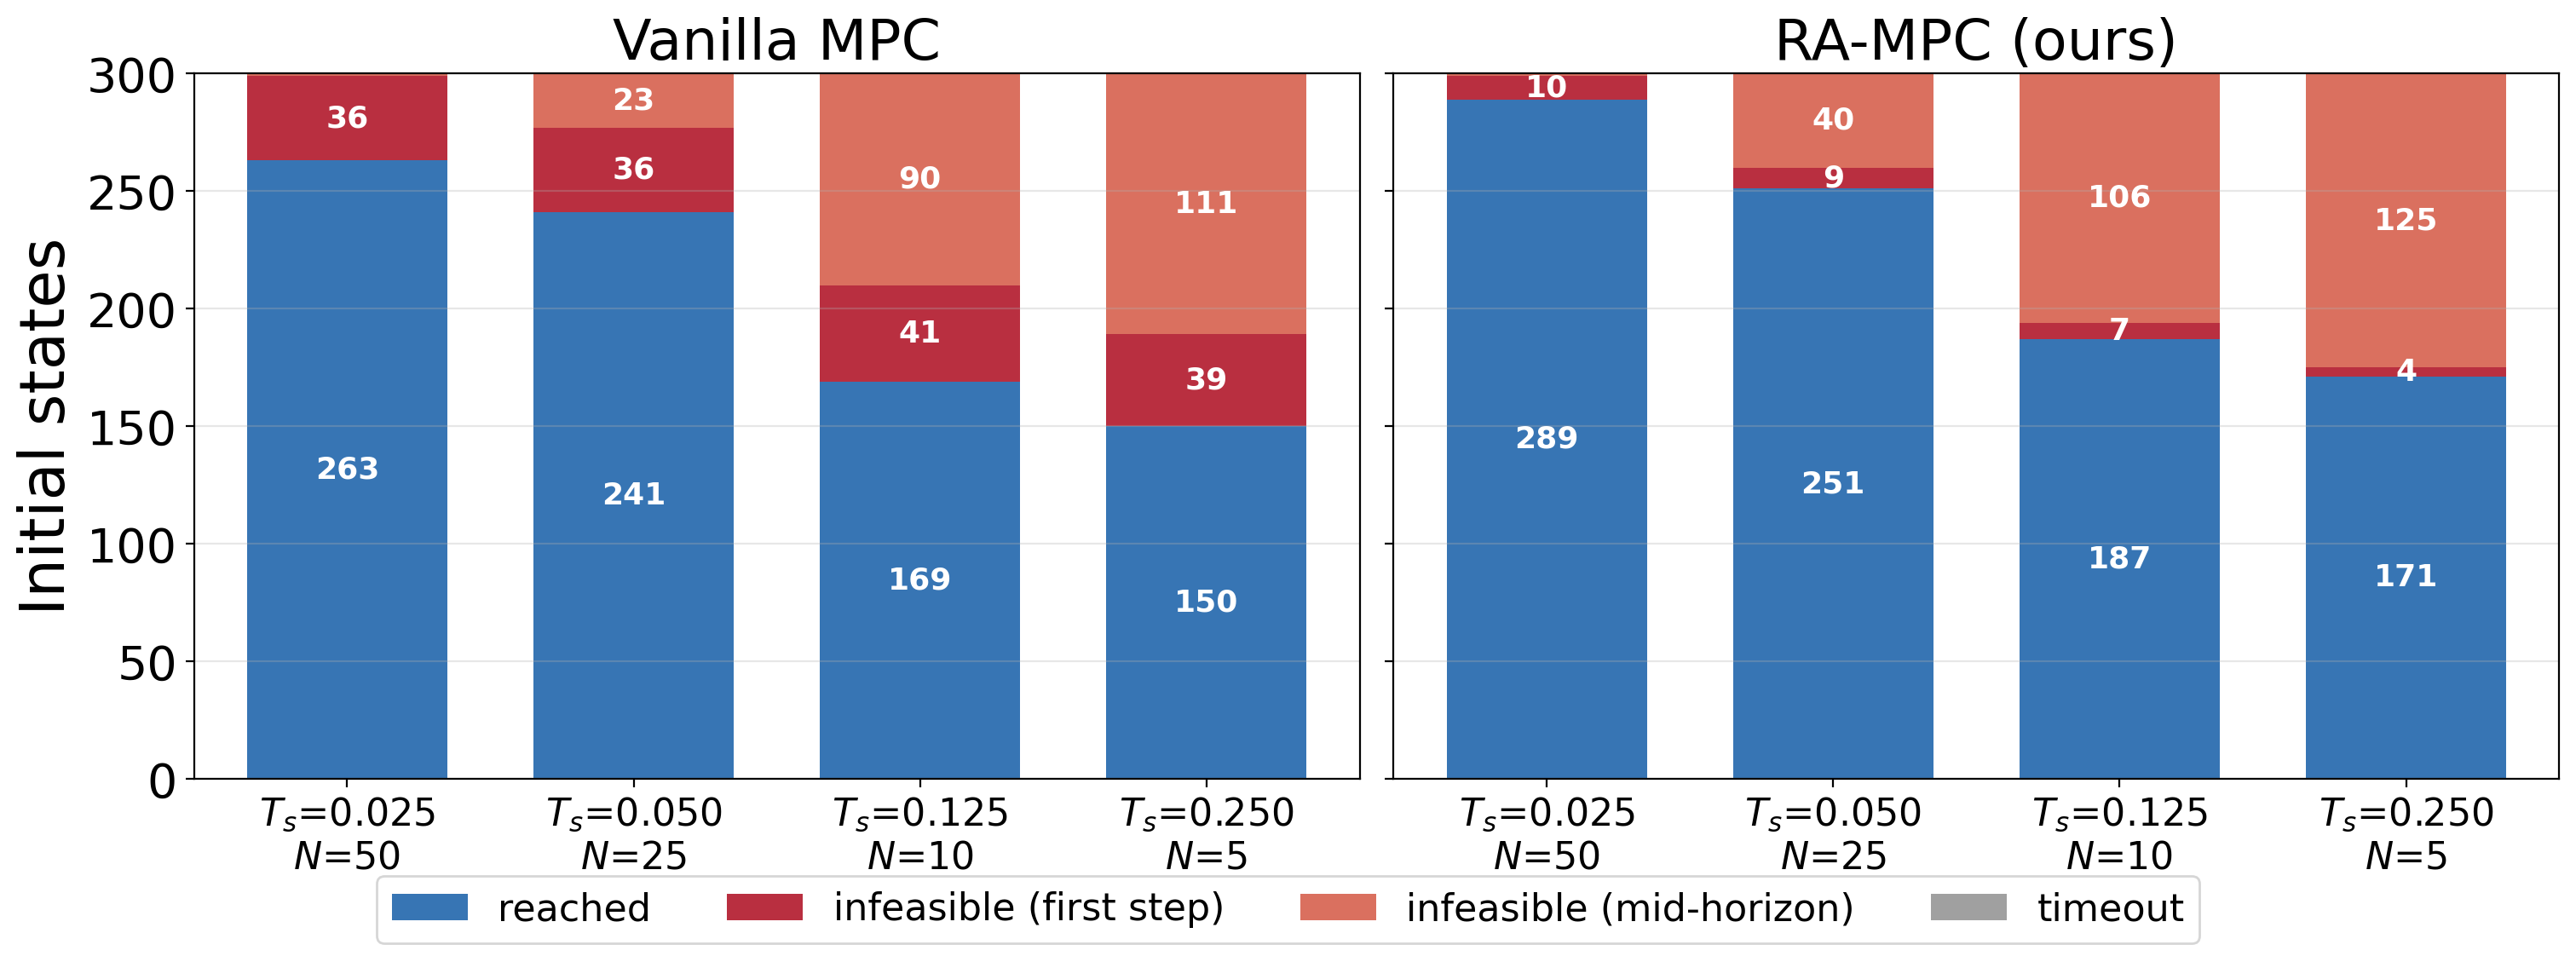

saved dubins_sweep_outcomes.png


In [28]:
# ── Plot 3: outcome breakdown over the candidates (one stacked bar per method) ─
# Colors stay in the main-notebook RdBu + gray family: blue = reached (good),
# reds = infeasible, gray = timeout (neutral).
oc_cols = ["n_reached", "n_infeas_s1", "n_infeas_mid", "n_timeout"]
oc_lab = ["reached", "infeasible (first step)", "infeasible (mid-horizon)", "timeout"]
oc_clr = ["#2166ac", "#b2182b", "#d6604d", "#969696"]

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, axes = plt.subplots(
    1, 2, figsize=(1500 * px_fig, 560 * px_fig), layout="constrained", sharey=True
)
fig.set_dpi(200)

for ax, m in zip(axes, methods):
    sub = summary[summary["method"] == m].sort_values("dt_mpc")
    xp = np.arange(len(sub))
    bottom = np.zeros(len(sub))
    for c, lbl, clr in zip(oc_cols, oc_lab, oc_clr):
        vals = sub[c].values.astype(float)
        ax.bar(xp, vals, bottom=bottom, label=lbl, color=clr, alpha=0.9, width=0.7)
        for xi, vi, bi in zip(xp, vals, bottom):
            if vi >= 3:
                ax.text(
                    xi,
                    bi + vi / 2,
                    f"{int(vi)}",
                    ha="center",
                    va="center",
                    fontsize=13,
                    color="white",
                    fontweight="bold",
                )
        bottom += vals
    ax.set_title(m, fontsize=fs - 6)
    ax.set_xticks(xp)
    ax.set_xticklabels(
        [f"$T_s$={c['dt_mpc']:.3f}\n$N$={c['N_hor']}" for c in CONFIGS], fontsize=16
    )
    ax.yaxis.set_tick_params(labelsize=20)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Initial states", fontsize=fs - 4)
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, fontsize=16, loc="outside lower center", ncol=4)
fig.savefig(
    os.path.join(REV_DATA, "dubins_sweep_outcomes.png"), dpi=200, bbox_inches="tight"
)
plt.show()
print("saved dubins_sweep_outcomes.png")